<a href="https://colab.research.google.com/github/Soumya78bhal/APPS/blob/main/FeatureScaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Create a sample dataset and save it to an Excel file

This dataset will include numerical features that can be used to practice various feature scaling techniques (e.g., standardization, normalization).

You can now download the `test_feature_scaling_data.xlsx` file from the Colab file browser (usually on the left-hand side under the folder icon) and use it for practicing feature scaling!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel('/content/test_feature_scaling_data.xlsx')
data

,Feature_A,Feature_B,Feature_C,Feature_D
0,66,63.028841,3.094245,0
1,85,896.216585,5.427112,1
2,49,32.227643,8.294055,0
3,55,28.298547,3.582046,1
4,61,679.460926,4.150532,1
5,81,491.778379,2.698288,1
6,89,205.656870,2.941149,1
7,70,356.663431,0.897914,1
8,43,68.711920,7.574860,1
9,40,802.645372,3.931536,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(data.drop('Feature_D',axis=1),
                                                    data['Feature_D'],
                                                    test_size=0.3,
                                                    random_state=101)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)



In [ ]:
scaled_X_test = pd.DataFrame(scaled_X_test,columns=X_test.columns)
scaled_X_train = pd.DataFrame(scaled_X_train,columns=X_train.columns)



In [ ]:
np.round(scaled_X_train.describe(),1)

,Feature_A,Feature_B,Feature_C
count,14.0,14.0,14.0
mean,0.0,0.0,-0.0
std,1.0,1.0,1.0
min,-1.6,-1.6,-1.0
25%,-1.0,-0.9,-0.8
50%,0.1,0.2,-0.2
75%,0.8,0.9,0.0
max,1.7,1.6,2.6


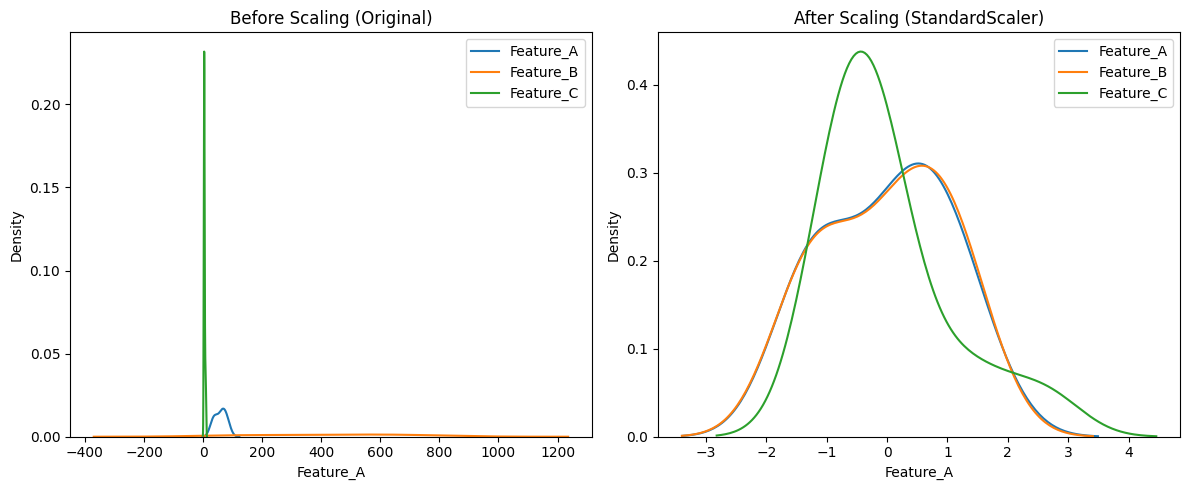

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title('Before Scaling (Original)')
for col in X_train.columns:
    sns.kdeplot(X_train[col], ax=ax1, label=col)
ax1.legend()

# 4. Plot Scaled Data (After Scaling)
ax2.set_title('After Scaling (StandardScaler)')
for col in scaled_X_train.columns:
    sns.kdeplot(scaled_X_train[col], ax=ax2, label=col)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logmodel= LogisticRegression()
logmodel.fit(scaled_X_train,Y_train)
predictions = logmodel.predict(scaled_X_test)

print("Accuracy Score:")
print(accuracy_score(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy Score:
0.6666666666666666

Confusion Matrix:
[[2 0]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.50      0.67         4

    accuracy                           0.67         6
   macro avg       0.75      0.75      0.67         6
weighted avg       0.83      0.67      0.67         6

